## PCA - Yacine Benmeziane

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Chargement du dataset
df = pd.read_csv('../data/city_lifestyle_dataset.csv')

# Sélection des colonnes numériques pour la PCA
# On exclut 'city_name' et 'country' qui sont des variables catégorielles
features = ['population_density', 'avg_income', 'internet_penetration', 'avg_rent', 
            'air_quality_index', 'public_transport_score', 'happiness_score', 'green_space_ratio']

X = df[features]

# La PCA est sensible aux échelles, on standardise donc les données
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Application de la PCA

In [5]:
# Initialisation et application de la PCA pour 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Création d'un DataFrame avec les résultats
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_pca['city_name'] = df['city_name']
df_pca['country'] = df['country']

# Affichage de la variance expliquée
print(f"Variance expliquée par PC1 : {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"Variance expliquée par PC2 : {pca.explained_variance_ratio_[1]*100:.2f}%")

Variance expliquée par PC1 : 53.81%
Variance expliquée par PC2 : 25.83%


### Visualisation Graphique

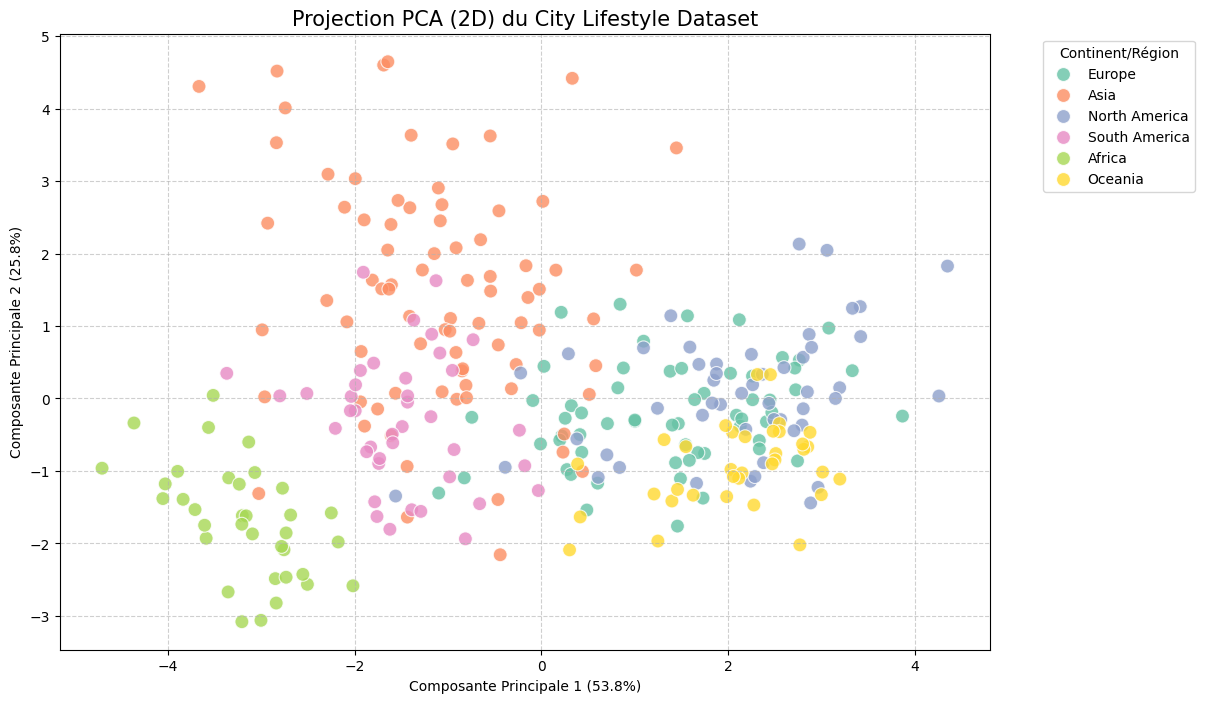

In [6]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC1', y='PC2', hue='country', data=df_pca, palette='Set2', s=100, alpha=0.8)

plt.title('Projection PCA (2D) du City Lifestyle Dataset', fontsize=15)
plt.xlabel(f'Composante Principale 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Composante Principale 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(title='Continent/Région', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Observations


On remarque une séparation distincte des villes selon leur situation géographique et économique. L'axe PC1 semble capturer le niveau de développement (revenus, internet, loyer), opposant souvent les villes d'Europe et d'Océanie aux villes d'Afrique. L'axe PC2 semble davantage lié à l'urbanisme (densité vs espaces verts). Les clusters par "country" montrent que les villes d'une même région partagent des caractéristiques de style de vie très similaires.

### Exportation des données

In [9]:
# Exportation du nouveau dataset réduit en 2D
df_pca.to_csv('../outputs/pca.csv', index=False)
print("Données exportées avec succès dans 'city_lifestyle_2d_pca.csv'")

Données exportées avec succès dans 'city_lifestyle_2d_pca.csv'
